# Show the simulated verificaition of dynamics on STANCE PHASE


In [10]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.io
import pandas as pd

In [11]:
# Loading the data

sim_data = pd.read_csv("data/stance.csv")
t_sim = sim_data['time'].to_numpy()
theta1_sim = sim_data['theta1'].to_numpy()
theta2_sim = sim_data['theta2'].to_numpy()

t_theo = scipy.io.loadmat("data/matlab_theo/t.mat")['t'].flatten()
theta1_theo = scipy.io.loadmat("data/matlab_theo/theta_1.mat")['theta_1'].flatten()
theta2_theo = scipy.io.loadmat("data/matlab_theo/theta_2.mat")['theta_2'].flatten()

In [12]:
# Calculate the Error
t_intervel = np.linspace(0, 10, 1000)
theta1_sim_intervel = np.interp(t_intervel, t_sim, theta1_sim)
theta2_sim_intervel = np.interp(t_intervel, t_sim, theta2_sim)
theta1_theo_intervel = np.interp(t_intervel, t_theo, theta1_theo)
theta2_theo_intervel = np.interp(t_intervel, t_theo, theta2_theo)

rmse_theta1 = np.sqrt(np.mean(np.square(theta1_sim_intervel-theta1_theo_intervel)))
rmse_theta2 = np.sqrt(np.mean(np.square(theta2_sim_intervel-theta2_theo_intervel)))
mae_theta1 = np.mean(np.abs(theta1_sim_intervel-theta1_theo_intervel))
mae_theta2 = np.mean(np.abs(theta2_sim_intervel-theta2_theo_intervel))
maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_theo_intervel))
maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_theo_intervel))

print(f"rmse_theta1: {rmse_theta1}\n"
        f"rmse_theta2: {rmse_theta2}\n"
        f"mae_theta1: {mae_theta1}\n"
        f"mae_theta2: {mae_theta2}\n"
        f"maxerror_theta1: {maxerror_theta1}\n"
        f"maxerror_theta2: {maxerror_theta2}")

rmse_theta1: 0.01698221597117871
rmse_theta2: 0.02840666214253265
mae_theta1: 0.015056543964986272
mae_theta2: 0.02659194109013315
maxerror_theta1: 0.03984774603501906
maxerror_theta2: 0.07910256739304722


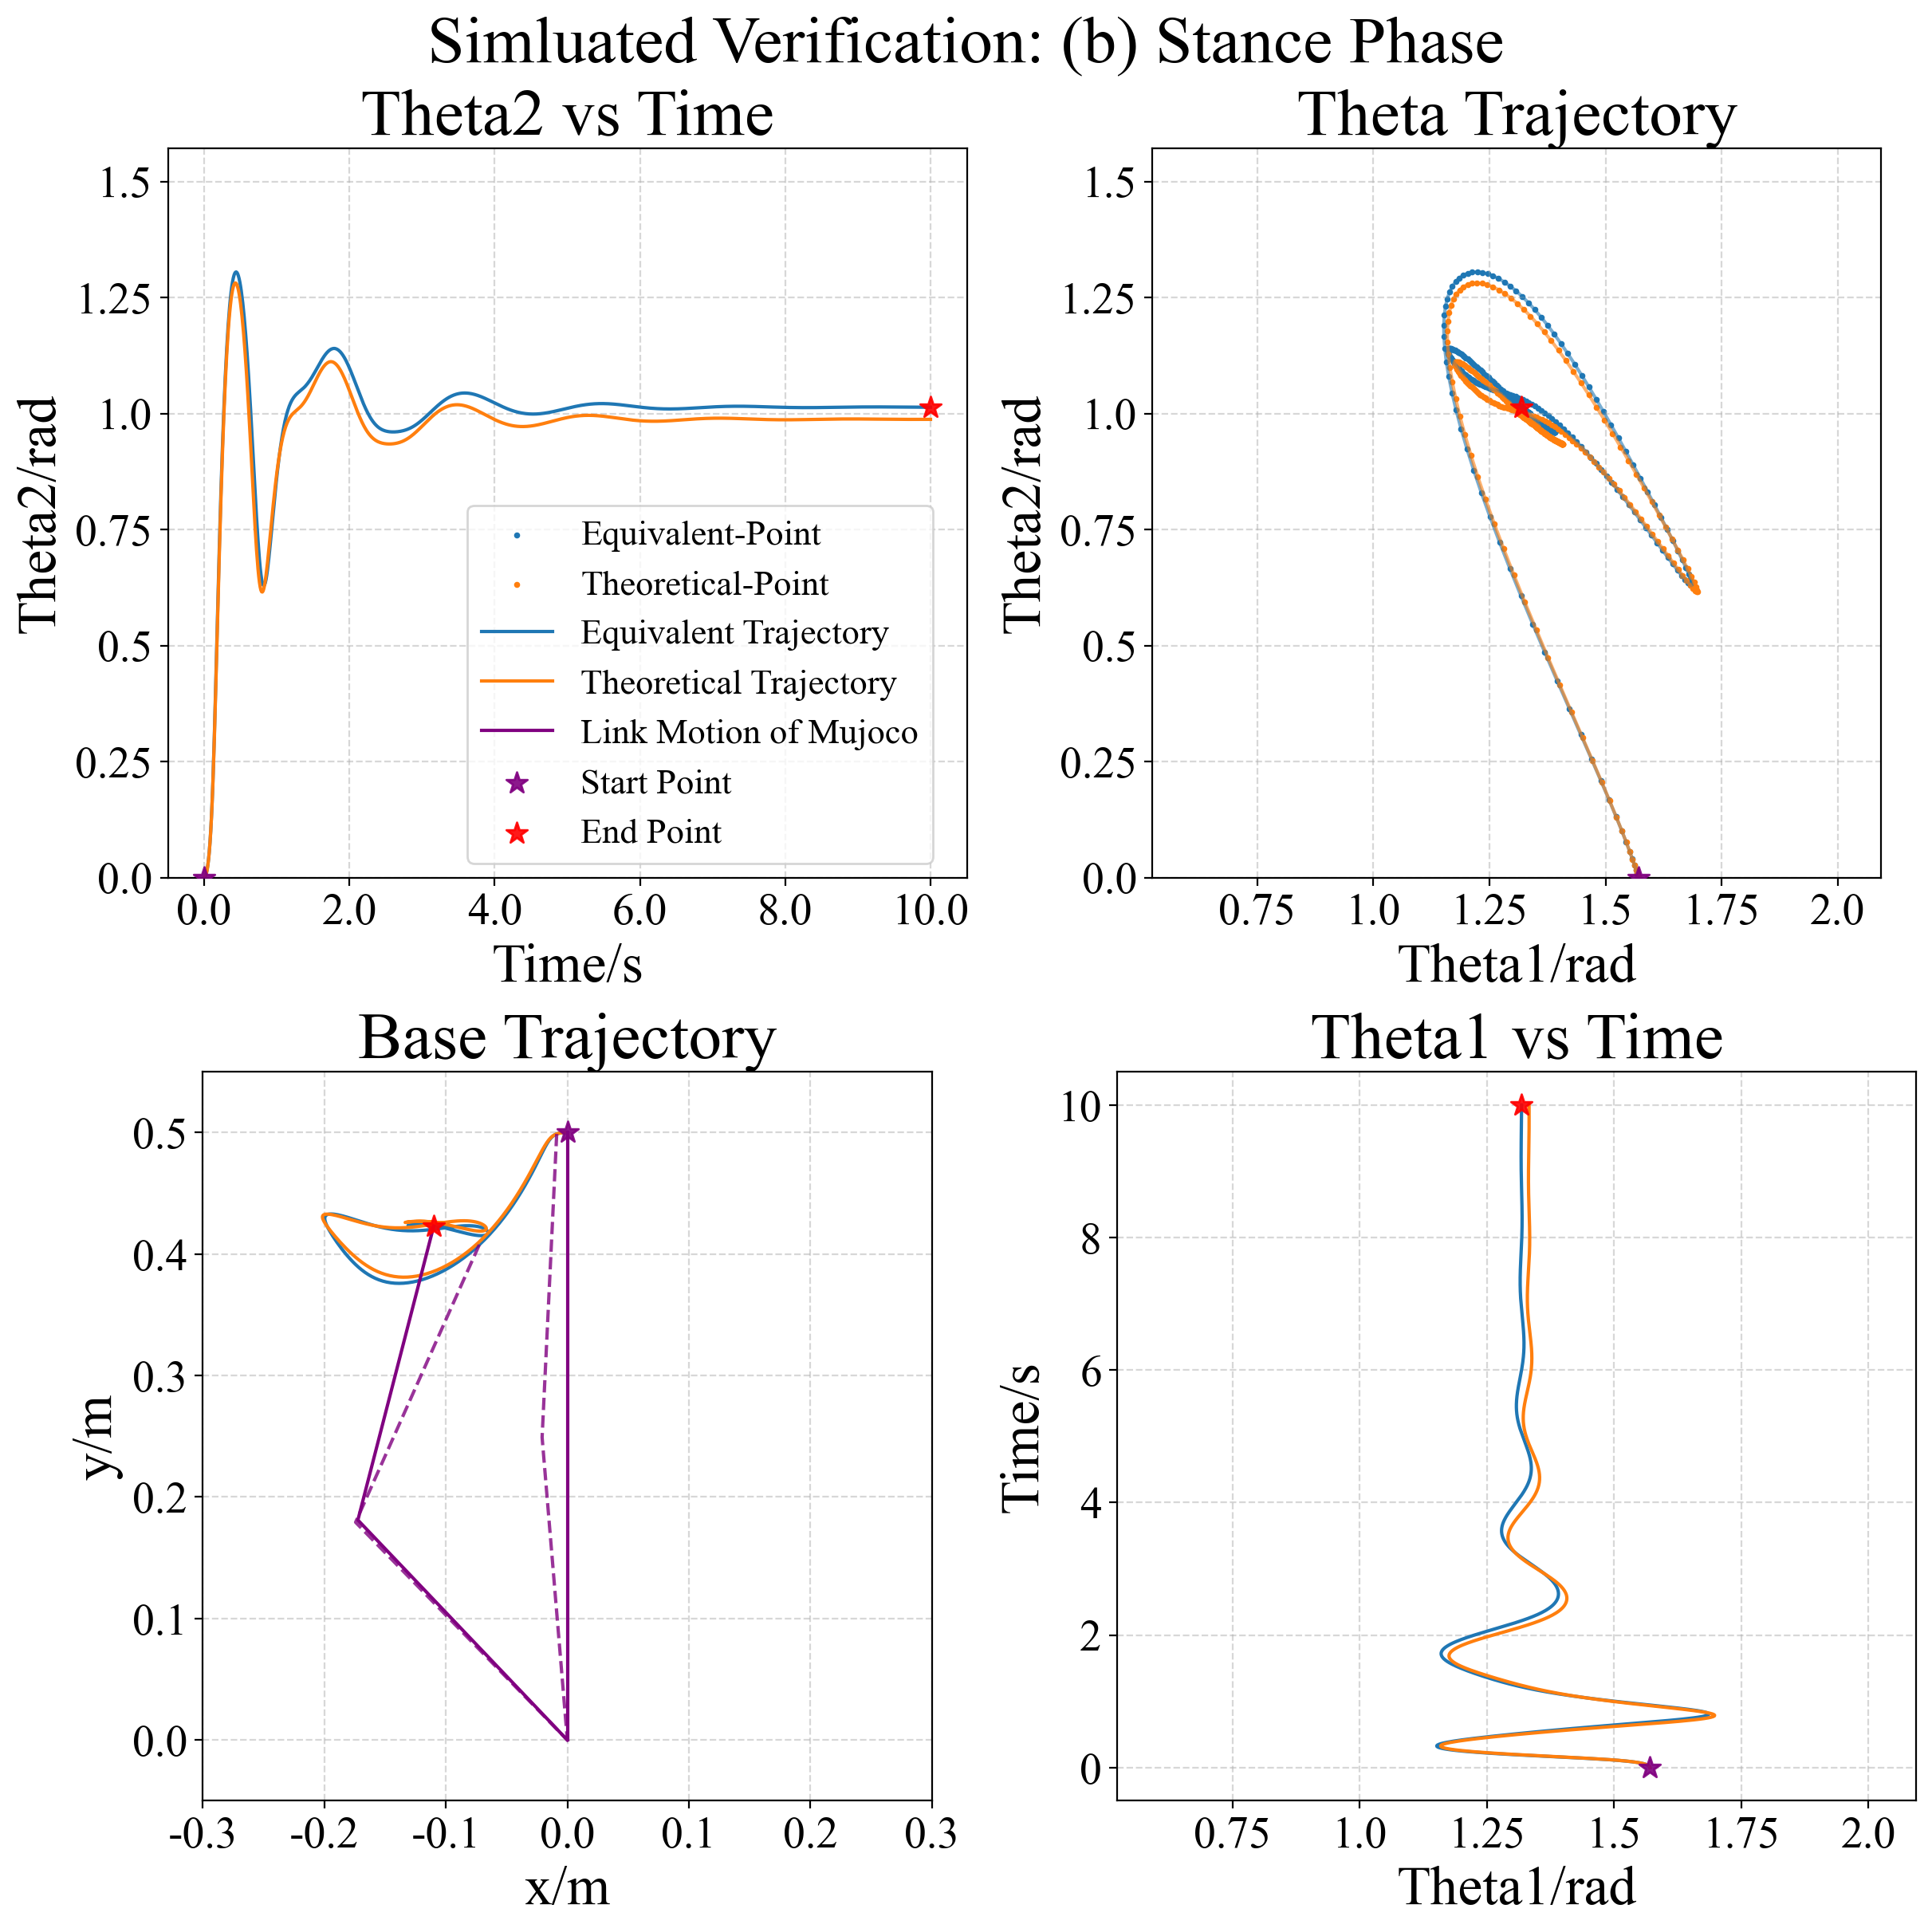

In [13]:
# Draw the step response of Stance Phase
from matplotlib import rcParams

config = {
    "font.family": 'Times New Roman',  # Set font type
    "axes.unicode_minus": False,  # Solve the problem of negative sign not displaying
    "font.size": 30,  # Set font size
    "axes.titlesize": 30,  # Set title font size
    "axes.labelsize": 25,  # Set axis label font size
    "xtick.labelsize": 20,  # Set x-axis tick font size
    "ytick.labelsize": 20,  # Set y-axis tick font size
}
rcParams.update(config)

legendSet = {
    'loc': 'upper right',
    'fontsize': 16,
}

# Plotting function
def update_plot():  
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=200, constrained_layout=True)  # Two rows and two columns layout
    
    # --- Top left: Time curve ---
    axs[0, 0].plot(t_intervel, theta2_sim_intervel)
    axs[0, 0].plot(t_intervel, theta2_theo_intervel)
    axs[0, 0].set_xlabel('Time/s')
    axs[0, 0].set_ylabel('Theta2/rad')
    axs[0, 0].set_title('Theta2 vs Time')
    axs[0, 0].grid(True, linestyle='--', alpha=0.5)

    # Mark start and end points
    axs[0, 0].scatter(t_intervel[0], theta2_sim_intervel[0], s=100, color='purple', marker='*', alpha=0.9, zorder=5)
    axs[0, 0].scatter(t_intervel[-1], theta2_sim_intervel[-1], s=100, color='red', marker='*', alpha=0.9, zorder=5)
    # axs[0, 0].legend(**legendSet)

    edge = math.pi/6 * 0
    axs[0, 0].set_ylim([0, math.pi/2])
    axs[0, 0].set_xlim([-0.5, 10.5])
    # Set ticks
    axs[0, 0].set_xticks(np.arange(0, 10.5, 2))
    axs[0, 0].set_xticklabels([f'{round(i, 0)}' for i in np.arange(0, 10.5, 2)])
    axs[0, 0].set_yticks(np.arange(0, math.pi/2+edge, 0.25))
    axs[0, 0].set_yticklabels([f'{round(i, 2)}' for i in np.arange(0, math.pi/2+edge, 0.25)])
    
    
    # --- Top right: Trajectory plot ---
    axs[0, 1].plot(theta1_sim_intervel, theta2_sim_intervel, alpha=0.6)  # Line
    axs[0, 1].scatter(theta1_sim_intervel, theta2_sim_intervel, s=3, label='Equivalent-Point')  # Scatter points
    axs[0, 1].plot(theta1_theo_intervel, theta2_theo_intervel, alpha=0.6)  # Line
    axs[0, 1].scatter(theta1_theo_intervel, theta2_theo_intervel, s=3, label='Theoretical-Point')  # Scatter points

    axs[0, 1].set_xlabel('Theta1/rad')
    axs[0, 1].set_ylabel('Theta2/rad')
    axs[0, 1].set_title('Theta Trajectory')
    axs[0, 1].set_xlim([math.pi/6-edge, math.pi*2/3+edge])
    axs[0, 1].set_ylim([0-edge, math.pi/2+edge])
    # Set grid spacing
    axs[0, 1].set_aspect('equal', adjustable='box')
    axs[0, 1].grid(True, linestyle='--', alpha=0.5)
    # Set xticks
    axs[0, 1].set_xticks(np.arange(0.75, math.pi*2/3+edge, 0.25))
    axs[0, 1].set_xticklabels([f'{round(i, 2)}' for i in np.arange(0.75, math.pi*2/3+edge, 0.25)])
    axs[0, 1].set_yticks(np.arange(0, math.pi/2+edge, 0.25))
    axs[0, 1].set_yticklabels([f'{round(i, 2)}' for i in np.arange(0, math.pi/2+edge, 0.25)])

    # Mark start and end points
    axs[0, 1].scatter(theta1_sim_intervel[0], theta2_sim_intervel[0], s=100, color='purple', marker='*', alpha=0.9, zorder=5)
    axs[0, 1].scatter(theta1_sim_intervel[-1], theta2_sim_intervel[-1], s=100, color='red', marker='*', alpha=0.9, zorder=5)
    
    # --- Bottom left: a_1cos(theta1) + a_2cos(theta2) ---
    a1 = 0.25  # You can adjust this value as needed
    a2 = 0.25  # You can adjust this value as needed
    # Use endpoint as offset, then reverse direction

    flip = -1  # You can adjust this value as needed

    x_mujoco = (a1 * np.cos(theta1_sim_intervel) + a2 * np.cos(theta2_sim_intervel + theta1_sim_intervel))
    y_mujoco = (a1 * np.sin(theta1_sim_intervel) + a2 * np.sin(theta2_sim_intervel + theta1_sim_intervel))
    x_matlab = (a1 * np.cos(theta1_theo_intervel) + a2 * np.cos(theta2_theo_intervel + theta1_theo_intervel))
    y_matlab = (a1 * np.sin(theta1_theo_intervel) + a2 * np.sin(theta2_theo_intervel + theta1_theo_intervel))

    knee_x_mujoco = (a1 * np.cos(theta1_sim_intervel))
    knee_y_mujoco = (a1 * np.sin(theta1_sim_intervel))
    knee_x_matlab = (a1 * np.cos(theta1_theo_intervel))
    knee_y_matlab = (a1 * np.sin(theta1_theo_intervel))

    zero_ = np.zeros_like(knee_x_mujoco)

    base_x_mujoco = zero_ - x_mujoco
    base_y_mujoco = zero_ - y_mujoco
    base_x_matlab = zero_ - x_matlab
    base_y_matlab = zero_ - y_matlab

    knee_x_mujoco = knee_x_mujoco - x_mujoco
    knee_y_mujoco = knee_y_mujoco - y_mujoco
    knee_x_matlab = knee_x_matlab - x_matlab
    knee_y_matlab = knee_y_matlab - y_matlab

    x_mujoco = x_mujoco - x_mujoco
    y_mujoco = y_mujoco - y_mujoco
    x_matlab = x_matlab - x_matlab
    y_matlab = y_matlab - y_matlab

    # flip
    x_mujoco = x_mujoco * flip
    y_mujoco = y_mujoco * flip
    x_matlab = x_matlab * flip
    y_matlab = y_matlab * flip
    knee_x_mujoco = knee_x_mujoco * flip
    knee_y_mujoco = knee_y_mujoco * flip
    knee_x_matlab = knee_x_matlab * flip
    knee_y_matlab = knee_y_matlab * flip
    base_x_mujoco = base_x_mujoco * flip
    base_y_mujoco = base_y_mujoco * flip
    base_x_matlab = base_x_matlab * flip
    base_y_matlab = base_y_matlab * flip


    axs[1, 0].plot(base_x_mujoco, base_y_mujoco, label='Equivalent Trajectory')
    axs[1, 0].plot(base_x_matlab, base_y_matlab, label='Theoretical Trajectory')

    # interesting point
    index_interesting = [0, -1, len(t_intervel)//30, len(t_intervel)//100]
    
    for index in index_interesting:
        # axs[1, 0].plot(np.array([zero_[index], knee_x_mujoco[index], x_mujoco[index]])-x_mujoco[index], np.array([zero_[index], knee_y_mujoco[index], y_mujoco[index]])-y_mujoco[index], '-' if index < 2 else '--', color='purple', markersize=10, alpha=1 if index < 2 else 0.8, label="Link Motion of Mujoco")
        axs[1, 0].plot([base_x_mujoco[index], knee_x_mujoco[index], x_mujoco[index]], [base_y_mujoco[index], knee_y_mujoco[index], y_mujoco[index]], '-' if index < 2 else '--', color='purple', markersize=10, alpha=1 if index < 2 else 0.8, label="Link Motion of Mujoco" if index==0 else "")

    # 标注起始点
    axs[1, 0].scatter(base_x_mujoco[0], base_y_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[1, 0].scatter(base_x_mujoco[-1], base_y_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)

    axs[1, 0].set_xlabel('x/m')
    axs[1, 0].set_ylabel('y/m')

    axs[1, 0].set_xlim([-0.3, 0.3])
    axs[1, 0].set_ylim(np.array([-0.05, 0.55]))

    # 设置tiks
    axs[1, 0].set_xticks(np.arange(-0.3, 0.35, 0.1))
    axs[1, 0].set_xticklabels([f'{round(i, 2)}' for i in np.arange(-0.3, 0.35, 0.1)])
    axs[1, 0].set_yticks(np.arange(0, 0.55, 0.1))
    axs[1, 0].set_yticklabels([f'{round(i, 2)}' for i in np.arange(0, 0.55, 0.1)])

    # 设置网格等距
    axs[1, 0].set_aspect('equal', adjustable='box')
    axs[1, 0].grid(True, linestyle='--', alpha=0.5)
    axs[1, 0].set_title('Base Trajectory')
    # axs[1, 0].legend(**legendSet)


    # --- 右下：theta2随时间变化 ---
    axs[1, 1].plot(theta1_sim_intervel, t_intervel)
    axs[1, 1].plot(theta1_theo_intervel, t_intervel)

    axs[1, 1].set_xlabel('Theta1/rad')
    axs[1, 1].set_ylabel('Time/s')

    # 标注起始点
    axs[1, 1].scatter(theta1_sim_intervel[0], t_intervel[0], s=100, color='purple', marker='*', alpha=0.9, zorder=5)
    axs[1, 1].scatter(theta1_sim_intervel[-1], t_intervel[-1], s=100, color='red', marker='*', alpha=0.9, zorder=5)

    axs[1, 1].set_title('Theta1 vs Time')
    axs[1, 1].set_xlim([math.pi/6, math.pi*2/3])
    # 设置网格等距
    # axs[1, 1].set_aspect('equal', adjustable='box')
    axs[1, 1].grid(True, linestyle='--', alpha=0.5)

    # 设置tiks
    axs[1, 1].set_xticks(np.arange(0.75, math.pi*2/3, 0.25))
    axs[1, 1].set_xticklabels([f'{round(i, 2)}' for i in np.arange(0.75, math.pi*2/3, 0.25)])
    axs[1, 1].set_yticks(np.arange(0, 11, 2))
    axs[1, 1].set_yticklabels([f'{round(i, 1)}' for i in np.arange(0, 11, 2)])
    
    # 添加全图 legend 到 axs[0, 0] 的左上角
    fig.legend(
        loc='upper left',
        bbox_to_anchor=(0.23, 0.75),  # 手动调整位置（关键点）
        fontsize=legendSet['fontsize'],
        frameon=True
    )

    fig.suptitle("Simluated Verification: (b) Stance Phase", fontsize=30)
    plt.show()

update_plot()